In [203]:
# 查看 iris.names 文件内容，了解数据集说明
with open('iris.names', 'r', encoding='utf-8') as f:
    content = f.read()
    print(content)

# 鸢尾花植物数据库
# 数据集三个类别，每类50个样本，共150个
# 一个类别(Setosa)与其他两个线性可分
# 但另外两个(Versicolor, Virginica)之间不是线性可分的
# 数据错误的情况已经经过了修改
# 每个样本4个数值型预测属性+1个类别标签
# 属性信息：
# sepal length in cm，花萼长度，单位厘米；
# sepal width in cm，花萼宽度，单位厘米；
# petal length in cm，花瓣长度，单位厘米；
# petal width in cm，花瓣长度，单位厘米
# 类别信息：
# Iris Setosa，山鸢尾；
# Iris Versicolour，变色鸢尾；
# Iris Virginica，维吉尼亚鸢尾（本实验的正类，因为是二分类问题）
# 无缺失值，类别均匀分布
# 统计摘要显示，花瓣长度和花瓣宽度与类别的相关性极高
# 各个特征取值范围接近，量纲一致，无需归一化

1. Title: Iris Plants Database
	Updated Sept 21 by C.Blake - Added discrepency information

2. Sources:
     (a) Creator: R.A. Fisher
     (b) Donor: Michael Marshall (MARSHALL%PLU@io.arc.nasa.gov)
     (c) Date: July, 1988

3. Past Usage:
   - Publications: too many to mention!!!  Here are a few.
   1. Fisher,R.A. "The use of multiple measurements in taxonomic problems"
      Annual Eugenics, 7, Part II, 179-188 (1936); also in "Contributions
      to Mathematical Statistics" (John Wiley, NY, 1950).
   2. Duda,R.O., & Hart,P.E. (1973) Pattern Classification and Scene Analysis.
      (Q327.D83) John Wiley & Sons.  ISBN 0-471-22361-1.  See page 218.
   3. Dasarathy, B.V. (1980) "Nosing Around the Neighborhood: A New System
      Structure and Classification Rule for Recognition in Partially Exposed
      Environments".  IEEE Transactions on Pattern Analysis and Machine
      Intelligence, Vol. PAMI-2, No. 1, 67-71.
      -- Results:
         -- very low misclassification rates (0% for t

In [204]:
import pandas as pd
import numpy as np

# 根据实验手册，IRIS数据集没有表头，需要手动指定列名
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# 读取数据文件
# 注意：iris.data 文件可能没有表头，使用 header=None
data = pd.read_csv('iris.data', header=None, names=columns)

# 输出数据基本信息
print("数据量为：", len(data))
print("\n数据集前5行：")
print(data.head())
print("\n数据集全部内容：")
print(data)

数据量为： 150

数据集前5行：
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

数据集全部内容：
     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0         

In [205]:
# 查看各列数据类型
print("数据类型：")
print(data.dtypes)
# 需要把类别标签转换为0/1的二值标签进行处理
print("\n各列数据数值分布（描述性统计）：")
print(data.describe())

# 查看类别分布
print("\n类别列唯一值：")
print(data['species'].unique())
print("\n各类别数量统计：")
print(data['species'].value_counts())

数据类型：
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

各列数据数值分布（描述性统计）：
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

类别列唯一值：
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

各类别数量统计：
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [206]:
# 统计空值数量
print("空值数量如下：")
print(data.isnull().sum())

# 跟文档写的一样，原始数据是没有缺失值的

空值数量如下：
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


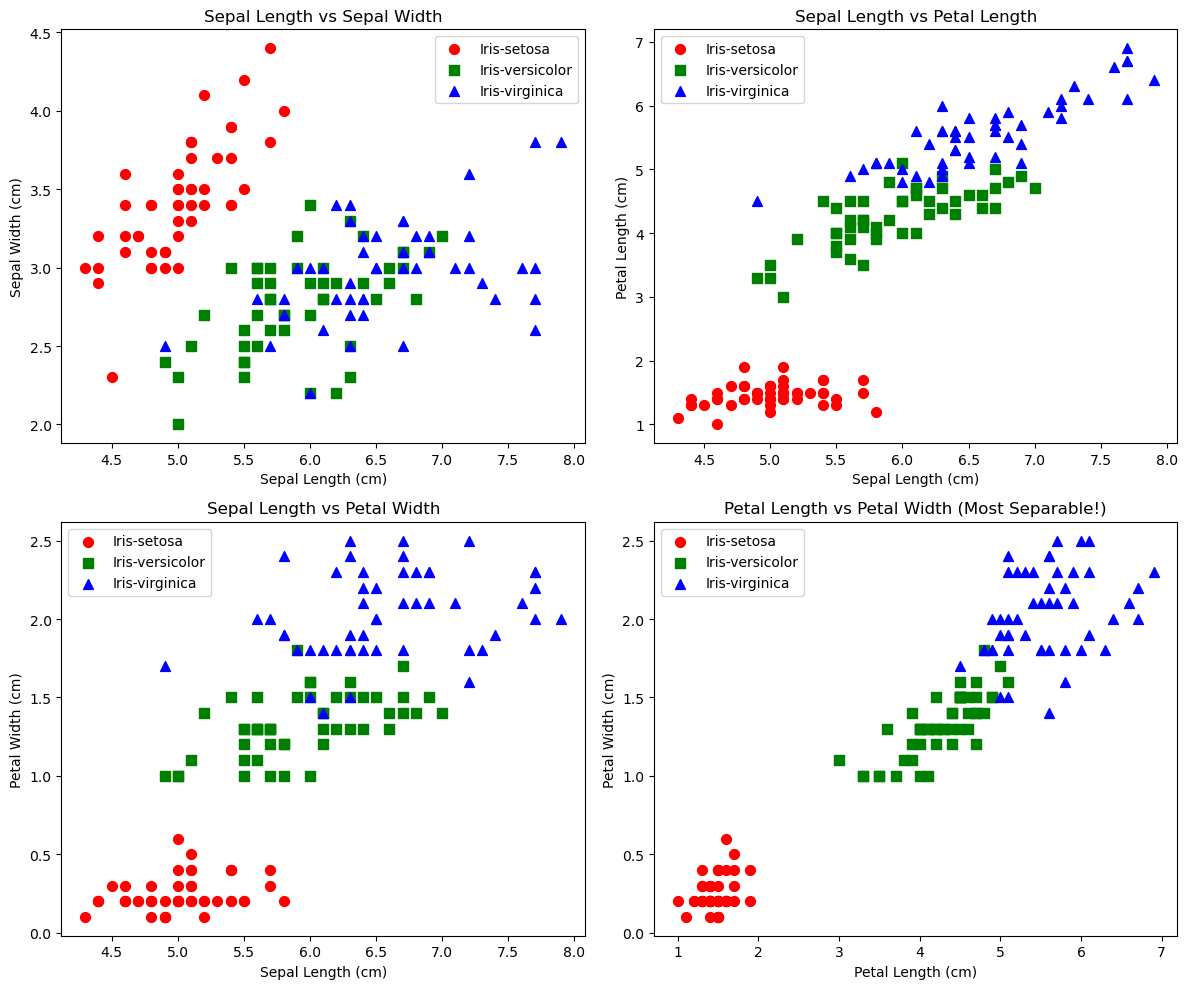

In [207]:
import matplotlib.pyplot as plt

# 创建2x2的子图，展示不同特征组合
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 恢复原始数据（3分类）用于可视化
data_orig = pd.read_csv('iris.data', header=None, names=columns)

# 定义颜色和标记
colors = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'}
markers = {'Iris-setosa': 'o', 'Iris-versicolor': 's', 'Iris-virginica': '^'}

# 1. 花萼长度 vs 花萼宽度
ax1 = axes[0, 0]
for species in data_orig['species'].unique():
    subset = data_orig[data_orig['species'] == species]
    ax1.scatter(subset['sepal_length'], subset['sepal_width'], 
                c=colors[species], marker=markers[species], label=species, s=50)
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')
ax1.set_title('Sepal Length vs Sepal Width')
ax1.legend()

# 2. 花萼长度 vs 花瓣长度
ax2 = axes[0, 1]
for species in data_orig['species'].unique():
    subset = data_orig[data_orig['species'] == species]
    ax2.scatter(subset['sepal_length'], subset['petal_length'], 
                c=colors[species], marker=markers[species], label=species, s=50)
ax2.set_xlabel('Sepal Length (cm)')
ax2.set_ylabel('Petal Length (cm)')
ax2.set_title('Sepal Length vs Petal Length')
ax2.legend()

# 3. 花萼长度 vs 花瓣宽度
ax3 = axes[1, 0]
for species in data_orig['species'].unique():
    subset = data_orig[data_orig['species'] == species]
    ax3.scatter(subset['sepal_length'], subset['petal_width'], 
                c=colors[species], marker=markers[species], label=species, s=50)
ax3.set_xlabel('Sepal Length (cm)')
ax3.set_ylabel('Petal Width (cm)')
ax3.set_title('Sepal Length vs Petal Width')
ax3.legend()

# 4. 花瓣长度 vs 花瓣宽度（最关键！）
ax4 = axes[1, 1]
for species in data_orig['species'].unique():
    subset = data_orig[data_orig['species'] == species]
    ax4.scatter(subset['petal_length'], subset['petal_width'], 
                c=colors[species], marker=markers[species], label=species, s=50)
ax4.set_xlabel('Petal Length (cm)')
ax4.set_ylabel('Petal Width (cm)')
ax4.set_title('Petal Length vs Petal Width (Most Separable!)')
ax4.legend()

plt.tight_layout()
plt.show()

In [208]:
# 将类别标签转换为二分类：virginica为1，其他为0
data['species'] = data['species'].apply(lambda x: 1 if x == 'Iris-virginica' else 0)

print("转换后的类别分布：")
print(data['species'].value_counts())
print("\n非virginica的数量（0）：", data['species'].value_counts()[0])
print("virginica的数量（1）：", data['species'].value_counts()[1])

print("\n转换后的数据前5行：")
print(data.head())

print("\n转换后的数据后5行：")
print(data.tail())

转换后的类别分布：
species
0    100
1     50
Name: count, dtype: int64

非virginica的数量（0）： 100
virginica的数量（1）： 50

转换后的数据前5行：
   sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0

转换后的数据后5行：
     sepal_length  sepal_width  petal_length  petal_width  species
145           6.7          3.0           5.2          2.3        1
146           6.3          2.5           5.0          1.9        1
147           6.5          3.0           5.2          2.0        1
148           6.2          3.4           5.4          2.3        1
149           5.9          3.0           5.1          1.8        1


In [209]:
from sklearn.model_selection import train_test_split

# 划分样本，7:3
train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)

print("原始数据量：", len(data))
print("训练集数据量：", len(train_data))
print("测试集数据量：", len(test_data))

# 准备X-y形式
# X为特征（前4列），y为标签（最后一列species）
col = train_data.shape[1]  # 总列数

X = train_data.iloc[:, 0:col-1].values      # 训练集特征
y = train_data.iloc[:, col-1:col].values    # 训练集标签
X_test = test_data.iloc[:, 0:col-1].values  # 测试集特征
y_test = test_data.iloc[:, col-1:col].values # 测试集标签

print("\n训练集X形状：", X.shape)
print("训练集y形状：", y.shape)
print("测试集X_test形状：", X_test.shape)
print("测试集y_test形状：", y_test.shape)

print("\nX矩阵示例（前5行）：")
print(X[:5])
print("\ny矩阵示例（前5行）：")
print(y[:5])

原始数据量： 150
训练集数据量： 105
测试集数据量： 45

训练集X形状： (105, 4)
训练集y形状： (105, 1)
测试集X_test形状： (45, 4)
测试集y_test形状： (45, 1)

X矩阵示例（前5行）：
[[5.5 2.4 3.7 1. ]
 [6.3 2.8 5.1 1.5]
 [6.4 3.1 5.5 1.8]
 [6.6 3.  4.4 1.4]
 [7.2 3.6 6.1 2.5]]

y矩阵示例（前5行）：
[[0]
 [1]
 [1]
 [0]
 [1]]


In [210]:
# 获取训练集和测试集的样本数
m = X.shape[0]  # 训练集行数
n = X_test.shape[0]  # 测试集行数

# 添加偏置项（第一列加1）
X = np.c_[np.ones(m), X]        # 训练集添加偏置列
X_test = np.c_[np.ones(n), X_test]  # 测试集添加偏置列

print("添加偏置项后X的形状：", X.shape)
print("添加偏置项后X_test的形状：", X_test.shape)

# 初始化参数theta（5×1的列向量，对应4个特征+1个偏置）
theta = np.zeros((X.shape[1], 1))

print("\ntheta初始形状：", theta.shape)
print("theta初始值：")
print(theta)

# 设置超参数
alpha = 0.01   # 学习率
iterations = 100000  # 迭代次数

添加偏置项后X的形状： (105, 5)
添加偏置项后X_test的形状： (45, 5)

theta初始形状： (5, 1)
theta初始值：
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [211]:
# 定义Sigmoid函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 定义损失函数
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    cost = -1/m * np.sum(y * np.log(h) + (1-y) * np.log(1-h))
    return cost

# 梯度下降函数（注意：y需要是列向量）
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    costs = []
    
    # 确保y是列向量
    y = y.reshape(-1, 1)
    
    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))
        theta = theta - alpha * gradient
        
        # 每100次迭代记录一次损失
        if i % 100 == 0:
            cost = compute_cost(X, y, theta)
            costs.append(cost)
    
    return theta, costs

In [212]:
# 执行梯度下降训练
theta_final, costs = gradient_descent(X, y, theta, alpha, iterations)

print("最终theta值：")
print(theta_final)

最终theta值：
[[-3.98882184]
 [-3.44681462]
 [-4.94217921]
 [ 5.83536861]
 [ 6.53012081]]


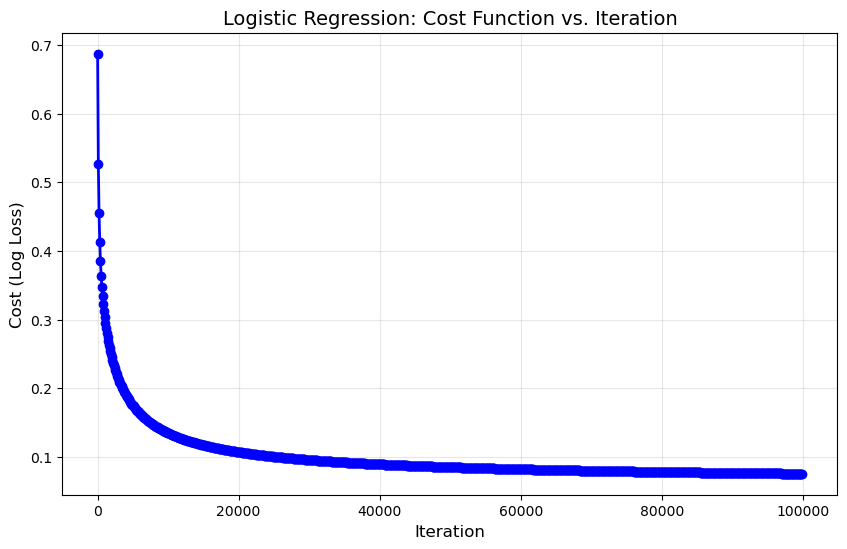

In [213]:
import matplotlib.pyplot as plt

# 绘制损失函数下降曲线
plt.figure(figsize=(10, 6))
plt.plot(range(0, iterations, 100), costs, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (Log Loss)', fontsize=12)
plt.title('Logistic Regression: Cost Function vs. Iteration', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [214]:
# 在测试集上进行预测
pred_prob = sigmoid(X_test @ theta_final)  # 预测概率

# 设置阈值0.5，转换为类别标签
pred_class = (pred_prob >= 0.5).astype(int)

print("测试集预测概率（前10个）：")
print(pred_prob[:10].flatten())
print("\n测试集预测类别（前10个）：")
print(pred_class[:10].flatten())
print("\n测试集真实标签（前10个）：")
print(y_test[:10].flatten())

测试集预测概率（前10个）：
[2.68541038e-02 5.47070786e-14 9.99993239e-01 4.98458353e-02
 1.60901883e-02 6.64375524e-13 2.95419308e-04 8.43837066e-01
 4.55734500e-01 1.19293146e-03]

测试集预测类别（前10个）：
[0 0 1 0 0 0 0 1 0 0]

测试集真实标签（前10个）：
[0 0 1 0 0 0 0 1 0 0]


In [215]:
# 将预测结果和真实标签展平为一维数组
pred_flat = pred_class.flatten()
y_test_flat = y_test.flatten()

# 计算准确率
correct_num = np.sum(pred_flat == y_test_flat)
accuracy = correct_num / n

print("正确预测个数为 {} 个，总个数有 {} 个".format(correct_num, n))
print("正确率为 {}".format(accuracy))

# 计算混淆矩阵
TP = np.sum((pred_flat == 1) & (y_test_flat == 1))
FP = np.sum((pred_flat == 1) & (y_test_flat == 0))
FN = np.sum((pred_flat == 0) & (y_test_flat == 1))
TN = np.sum((pred_flat == 0) & (y_test_flat == 0))

print("\nTP为 {}".format(TP))
print("FP为 {}".format(FP))
print("FN为 {}".format(FN))
print("TN为 {}".format(TN))

# 计算Precision、Recall、F1-Score
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\nPrecision: {}".format(precision))
print("Recall: {}".format(recall))
print("F1-score: {}".format(f1_score))
print("accuracy: {}".format(accuracy))

正确预测个数为 45 个，总个数有 45 个
正确率为 1.0

TP为 13
FP为 0
FN为 0
TN为 32

Precision: 1.0
Recall: 1.0
F1-score: 1.0
accuracy: 1.0


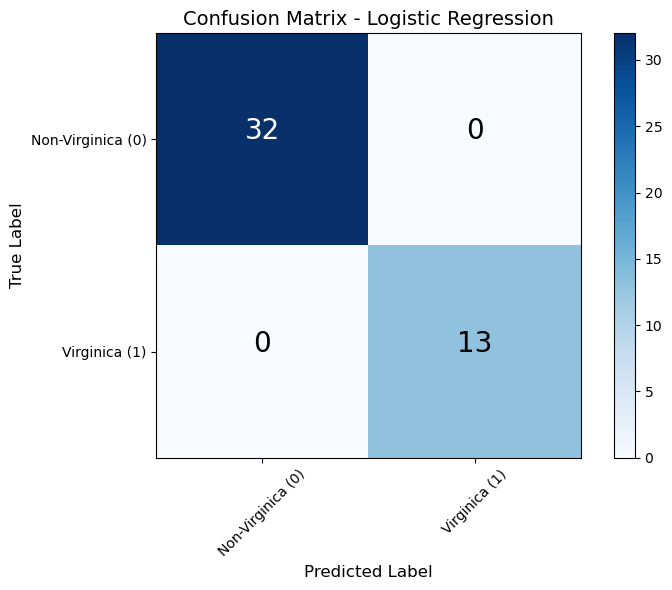

In [216]:
import matplotlib.pyplot as plt
import numpy as np

# 构建混淆矩阵
confusion_matrix = np.array([[TN, FP],
                             [FN, TP]])

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.colorbar()

# 设置坐标轴
classes = ['Non-Virginica (0)', 'Virginica (1)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# 在每个格子中显示数值
thresh = confusion_matrix.max() / 2.
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(confusion_matrix[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if confusion_matrix[i, j] > thresh else "black",
                 fontsize=20)

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [217]:
# 使用原始的训练集数据（不带偏置项的X）
# 需要从X中去掉第一列（偏置项），恢复为原始4个特征
X_train_orig = X[:, 1:]  # 去掉偏置列，形状为(105, 4)

# 将y展平为一维数组（便于布尔索引）
y_flat = y.flatten()

print("X_train_orig形状：", X_train_orig.shape)
print("y_flat形状：", y_flat.shape)

# 计算先验概率
v_prior = np.mean(y_flat)      # Virginica的先验概率 P(C=1)
nv_prior = 1 - v_prior         # 非Virginica的先验概率 P(C=0)

print("\nVirginica类(1)的样本数：", np.sum(y_flat == 1))
print("非Virginica类(0)的样本数：", np.sum(y_flat == 0))
print("Virginica先验概率 P(C=1)：", v_prior)
print("非Virginica先验概率 P(C=0)：", nv_prior)

X_train_orig形状： (105, 4)
y_flat形状： (105,)

Virginica类(1)的样本数： 37
非Virginica类(0)的样本数： 68
Virginica先验概率 P(C=1)： 0.3523809523809524
非Virginica先验概率 P(C=0)： 0.6476190476190475


In [218]:
# 计算每个类别、每个特征的均值和标准差
# Virginica类（y == 1）
mean_v = X_train_orig[y_flat == 1].mean(axis=0)   # 形状(4,)
std_v = X_train_orig[y_flat == 1].std(axis=0)     # 形状(4,)

# 非Virginica类（y == 0）
mean_nv = X_train_orig[y_flat == 0].mean(axis=0)  # 形状(4,)
std_nv = X_train_orig[y_flat == 0].std(axis=0)    # 形状(4,)

print("Virginica类特征均值：", mean_v)
print("Virginica类特征标准差：", std_v)
print("\n非Virginica类特征均值：", mean_nv)
print("非Virginica类特征标准差：", std_nv)

# 为了防止除以0，对标准差加一个极小值
epsilon = 1e-9
std_v = std_v + epsilon
std_nv = std_nv + epsilon

print("\n（已添加平滑项防止除零）")

Virginica类特征均值： [6.55945946 2.98648649 5.54594595 2.00540541]
Virginica类特征标准差： [0.64993116 0.31032865 0.53705634 0.29311555]

非Virginica类特征均值： [5.45294118 3.01470588 2.96029412 0.82058824]
非Virginica类特征标准差： [0.63302973 0.45898376 1.4183814  0.55268298]

（已添加平滑项防止除零）


In [219]:
# 高斯分布概率密度函数
def gaussian_prob(x, mean, std):
    return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# 预测函数（使用对数概率防止下溢）
def predict_naive_bayes(X):
    predictions = []
    
    for x in X:
        # 计算Virginica类的对数后验概率
        log_prob_v = np.log(v_prior)
        for i in range(len(x)):
            p = gaussian_prob(x[i], mean_v[i], std_v[i])
            log_prob_v += np.log(p + epsilon)
        
        # 计算非Virginica类的对数后验概率
        log_prob_nv = np.log(nv_prior)
        for i in range(len(x)):
            p = gaussian_prob(x[i], mean_nv[i], std_nv[i])
            log_prob_nv += np.log(p + epsilon)
        
        # 选择概率大的类别
        predictions.append(1 if log_prob_v > log_prob_nv else 0)
    
    return np.array(predictions)

In [220]:
# 准备测试集（去掉偏置项）
X_test_orig = X_test[:, 1:]

# 进行预测
pred_nb = predict_naive_bayes(X_test_orig)
y_test_flat = y_test.flatten()

# 计算准确率
correct_num_nb = np.sum(pred_nb == y_test_flat)
accuracy_nb = correct_num_nb / n

print("\n正确预测个数为 {} 个，总个数有 {} 个".format(correct_num_nb, n))
print("正确率为 {}".format(accuracy_nb))

# 计算混淆矩阵
TP_nb = np.sum((pred_nb == 1) & (y_test_flat == 1))
FP_nb = np.sum((pred_nb == 1) & (y_test_flat == 0))
FN_nb = np.sum((pred_nb == 0) & (y_test_flat == 1))
TN_nb = np.sum((pred_nb == 0) & (y_test_flat == 0))

print("\nTP为 {}".format(TP_nb))
print("FP为 {}".format(FP_nb))
print("FN为 {}".format(FN_nb))
print("TN为 {}".format(TN_nb))

# 计算评估指标
precision_nb = TP_nb / (TP_nb + FP_nb) if (TP_nb + FP_nb) > 0 else 0
recall_nb = TP_nb / (TP_nb + FN_nb) if (TP_nb + FN_nb) > 0 else 0
f1_score_nb = 2 * precision_nb * recall_nb / (precision_nb + recall_nb) if (precision_nb + recall_nb) > 0 else 0

print("\nPrecision: {}".format(precision_nb))
print("Recall: {}".format(recall_nb))
print("F1-score: {}".format(f1_score_nb))
print("accuracy: {}".format(accuracy_nb))


正确预测个数为 41 个，总个数有 45 个
正确率为 0.9111111111111111

TP为 13
FP为 4
FN为 0
TN为 28

Precision: 0.7647058823529411
Recall: 1.0
F1-score: 0.8666666666666666
accuracy: 0.9111111111111111


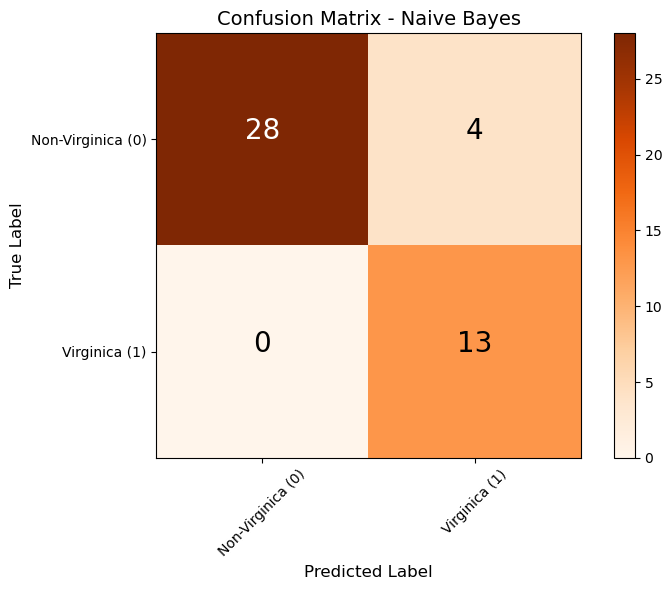

In [221]:
import matplotlib.pyplot as plt
import numpy as np

# 构建混淆矩阵
confusion_matrix_nb = np.array([[TN_nb, FP_nb],
                                [FN_nb, TP_nb]])

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_nb, interpolation='nearest', cmap=plt.cm.Oranges)
plt.title('Confusion Matrix - Naive Bayes', fontsize=14)
plt.colorbar()

# 设置坐标轴
classes = ['Non-Virginica (0)', 'Virginica (1)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# 在每个格子中显示数值
thresh = confusion_matrix_nb.max() / 2.
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(confusion_matrix_nb[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if confusion_matrix_nb[i, j] > thresh else "black",
                 fontsize=20)

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

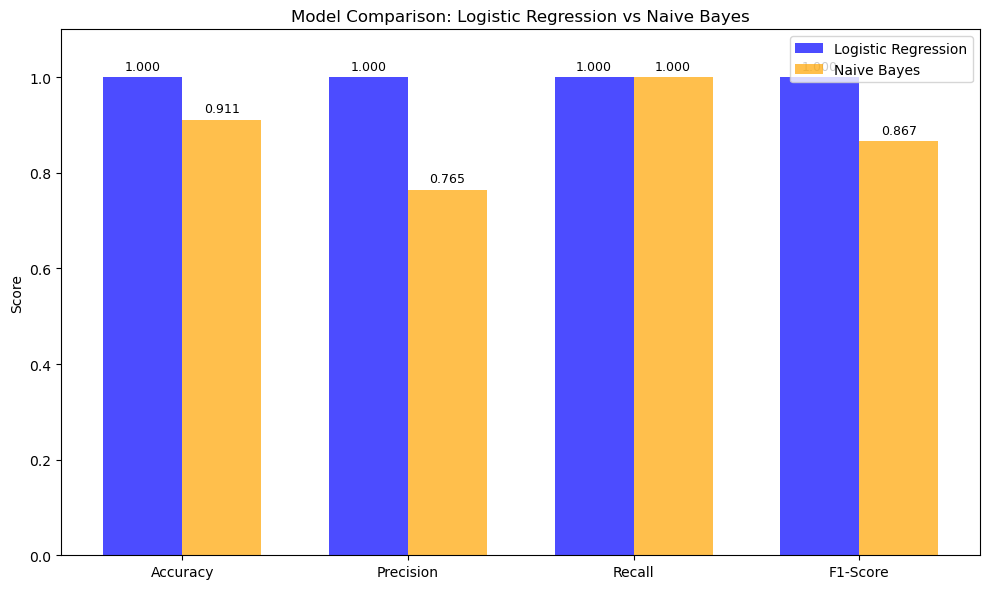

In [222]:
import matplotlib.pyplot as plt
import numpy as np

# 指标对比数据
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
logistic_scores = [1.0, 1.0, 1.0, 1.0]
naive_bayes_scores = [0.9111, 0.7647, 1.0, 0.8667]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, logistic_scores, width, label='Logistic Regression', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, naive_bayes_scores, width, label='Naive Bayes', color='orange', alpha=0.7)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Logistic Regression vs Naive Bayes')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

# 在柱子上显示数值
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

各列数据数值分布（描述性统计）：
       sepal_length  sepal_width  petal_length  petal_width     species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.054000      3.758667     1.198667    0.333333
std        0.828066     0.433594      1.764420     0.763161    0.472984
min        4.300000     2.000000      1.000000     0.100000    0.000000
25%        5.100000     2.800000      1.600000     0.300000    0.000000
50%        5.800000     3.000000      4.350000     1.300000    0.000000
75%        6.400000     3.300000      5.100000     1.800000    1.000000
max        7.900000     4.400000      6.900000     2.500000    1.000000


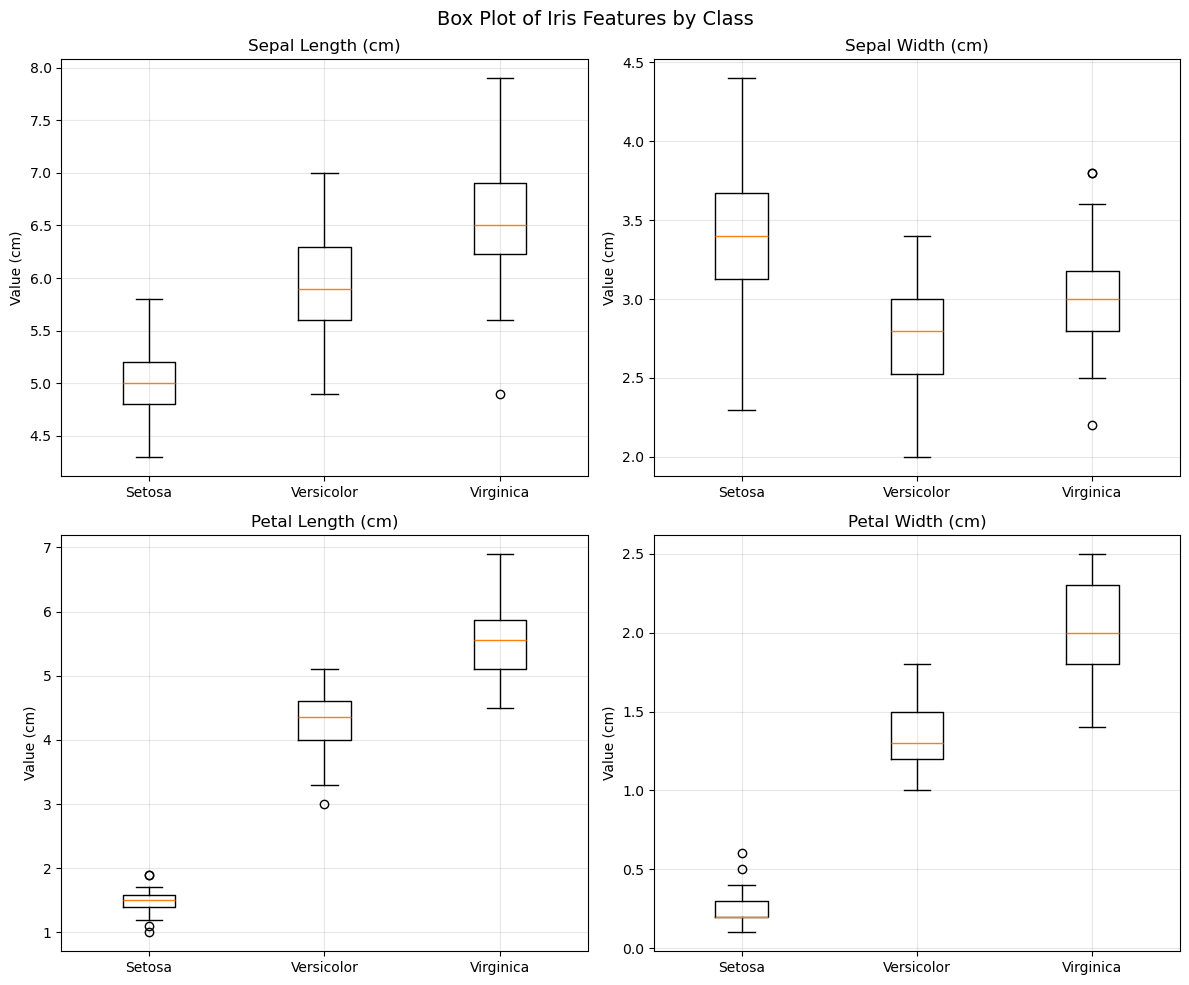


箱线图说明：
1. 每个子图展示一个特征在三个类别中的分布
2. 箱体表示四分位距（IQR），中线表示中位数
3. 圆点表示异常值
4. 可以直观看出Setosa与其他两类的差异


In [223]:
import matplotlib.pyplot as plt

# 恢复原始数据（3分类）用于可视化
data_orig = pd.read_csv('iris.data', header=None, names=columns)

# 描述性统计
print("各列数据数值分布（描述性统计）：")
print(data.describe())

# 绘制箱线图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

for idx, (feature, title) in enumerate(zip(features, titles)):
    ax = axes[idx // 2, idx % 2]
    
    # 为每个类别绘制箱线图
    data_to_plot = [data_orig[data_orig['species'] == species][feature] 
                    for species in data_orig['species'].unique()]
    
    # 使用 tick_labels 替代 labels（兼容新版Matplotlib）
    bp = ax.boxplot(data_to_plot, tick_labels=['Setosa', 'Versicolor', 'Virginica'])
    ax.set_title(title)
    ax.set_ylabel('Value (cm)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Box Plot of Iris Features by Class', fontsize=14)
plt.tight_layout()
plt.show()

print("\n箱线图说明：")
print("1. 每个子图展示一个特征在三个类别中的分布")
print("2. 箱体表示四分位距（IQR），中线表示中位数")
print("3. 圆点表示异常值")
print("4. 可以直观看出Setosa与其他两类的差异")